In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata
import requests
import math
import time
from io import StringIO
import os

ModuleNotFoundError: No module named 'geopandas'

In [4]:
NASA_POWER_API_URL = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=RE&longitude={lon}&latitude={lat}&start={start}&end={end}&format=CSV"
NASA_POWER_BATCH_SIZE = 10
NASA_MISSING_VALUE = -999

UGANDA_SHAPEFILE = "Data/gadm41_UGA_shp/gadm41_UGA_0.shp"
OUTPUT_FILENAME = 'uganda_ghi_heatmap.png'
GHI_PARAMETER = 'ALLSKY_SFC_SW_DWN'
START_DATE= '2021-01-01'
END_DATE = '2021-12-31'
GRID_SPACING_DEGREES = 0.05  # Adjust this value to change the grid spacing
INTERPORATION_METHOD = 'nearest'  # 'linear', 'nearest', or 'cubic'
COLOR_MAP = 'YlOrRd'

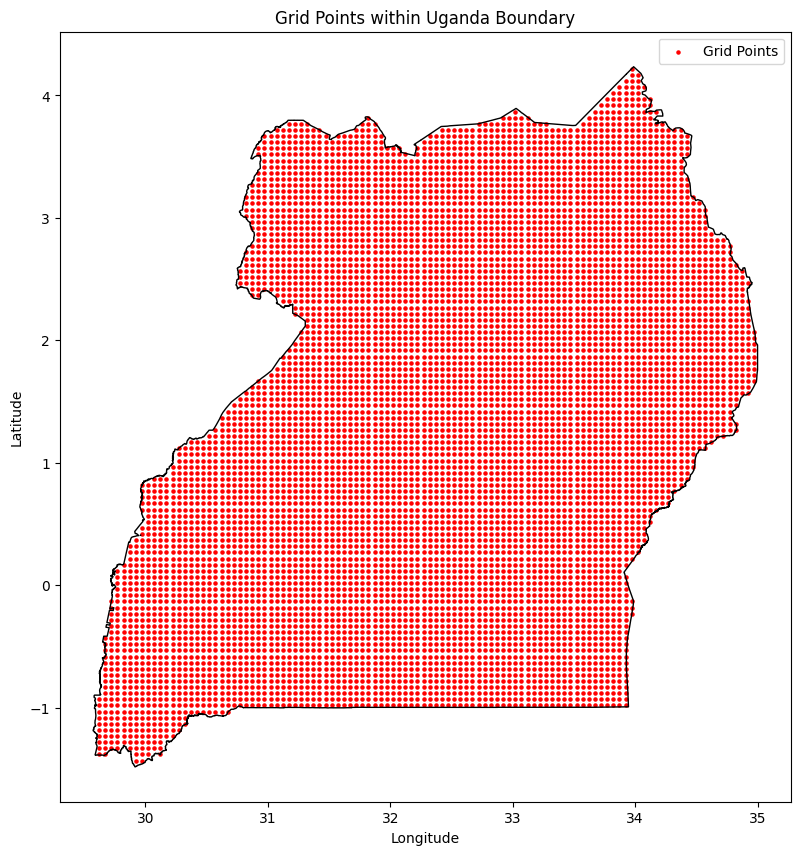

In [5]:
uganda_map = gpd.read_file(UGANDA_SHAPEFILE)
uganda_map = uganda_map.to_crs(epsg=4326)  # Convert to WGS84
uganda_boundary = uganda_map.union_all() 
uganda_boundary = uganda_boundary.buffer(0)  # Fix geometry issues

minx, miny, maxx, maxy = uganda_boundary.bounds

# Create a grid of points within the Uganda boundary
lon_grid = np.arange(minx, maxx, GRID_SPACING_DEGREES)
lat_grid = np.arange(miny, maxy, GRID_SPACING_DEGREES)
lons, lats = np.meshgrid(lon_grid, lat_grid)
grid_points = [Point(lon, lat) for lon, lat in zip(lons.flatten(), lats.flatten())]

# Filter grid points to only include those within the Uganda boundary
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs=uganda_map.crs)
grid_gdf = grid_gdf[grid_gdf.within(uganda_boundary)]

# Prepare location data for NASA POWER API
locations = {}

for i, point in grid_gdf.iterrows():
    loc_name = f"point_{i}"
    locations[loc_name] = {
        'lat': point.geometry.y,
        'lon': point.geometry.x,
        'Start Time': START_DATE,
        'End Time' : END_DATE
    }
    
# plot the Uganda map indicating the grid points
fig, ax = plt.subplots(figsize=(10, 10))
uganda_map.boundary.plot(ax=ax, color='black', linewidth=1)
grid_gdf.plot(ax=ax, color='red', markersize=5, label='Grid Points')
plt.title('Grid Points within Uganda Boundary')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

In [5]:
# Function to fetch data from NASA POWER API
def fetch_nasa_power_data(locations_dict, parameter_list):
    if not isinstance(locations_dict, dict):
        raise TypeError("locations_dict must be a dictionary")
    if not isinstance(parameter_list, list):
        raise TypeError("parameter_list must be a list")

    num_batches = math.ceil(len(parameter_list) / NASA_POWER_BATCH_SIZE)
    
    all_location_dfs = []
    metadata_dict = {}
    
    for location_idx, (location_name, details) in enumerate(locations_dict.items()):
        print(f"Fetching data for {location_name} ({location_idx + 1}/{len(locations_dict)})")
        start_date_api = details['Start Time'].replace("-", "")
        end_date_api = details['End Time'].replace("-", "")
        latitude = details['lat']
        longitude = details['lon']
        
        location_batch_dfs = []
        failed_location = False
        
        for i in range(num_batches):
            batch_start_idx = i * NASA_POWER_BATCH_SIZE
            batch_end_idx = batch_start_idx + NASA_POWER_BATCH_SIZE
            parameter_batch = parameter_list[batch_start_idx:batch_end_idx]
            parameter_str = ','.join(parameter_batch)
            
            print(f'Batch {i + 1}/{num_batches} for {location_name}: Retrieving {parameter_str}')
            
            api_url = NASA_POWER_API_URL.format(
                parameters=parameter_str,
                lat=latitude,
                lon=longitude,
                start=start_date_api,
                end=end_date_api
            )
            
            try:
                response = requests.get(api_url, verify=True, timeout=60)
                response.raise_for_status()
                
                content = response.content.decode('utf-8')
                lines = content.split('\n')
                
                # timedelay to avoid hitting the API too fast
                time.sleep(1)
                
                try:
                    header_row_index = next(i for i, line in enumerate(lines) if line.strip().startswith('YEAR,MO,DY'))
                except StopIteration:
                    print(f"Header row not found in response for {location_name}.")
                    failed_location = True
                    break
                
                if location_name not in metadata_dict:
                    metadata = '\n'.join(lines[:header_row_index])
                    metadata_dict[location_name] = {'metadata': metadata}
                
                csv_data = StringIO('\n'.join(lines[header_row_index:]))
                
                na_vals_batch = {col: NASA_MISSING_VALUE for col in parameter_batch}
                df_batch = pd.read_csv(csv_data, na_values=na_vals_batch)
                
                if not all(col in df_batch.columns for col in ['YEAR', 'MO', 'DY']):
                    print(f"Missing date columns in response for {location_name}.")
                    continue
                
                df_batch.rename(columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'}, inplace=True)
                
                if df_batch.empty:
                    print(f"No data returned for {location_name}.")
                    failed_location = True
                    continue
                
                df_batch['datetime'] = pd.to_datetime(df_batch[['year', 'month', 'day']], errors='coerce')
                df_batch.dropna(subset=['datetime'], inplace=True)
                if df_batch.empty:
                    print(f"No valid datetime data for {location_name}.")
                    failed_location = True
                    continue
                df_batch.set_index('datetime', inplace=True)
                
                cols_to_keep = [col for col in parameter_batch if col in df_batch.columns]
                if len(cols_to_keep) != len(parameter_batch):
                    missing_cols = set(parameter_batch) - set(cols_to_keep)
                    print(f"Missing columns in response for {location_name}: {missing_cols}")
                    
                if not cols_to_keep:
                    print(f"No valid data columns for {location_name}.")
                    continue
                df_batch = df_batch[cols_to_keep]
                
                for col in df_batch.columns:
                    df_batch[col] = pd.to_numeric(df_batch[col], errors='coerce')
                    df_batch[col] = df_batch[col].replace(NASA_MISSING_VALUE, np.nan)
                
                location_batch_dfs.append(df_batch)

            except TimeoutError:
                print(f"Timeout error for {location_name}. Retrying...")
                failed_location = True
                break
            except requests.exceptions.RequestException as e:
                print(f"Request error for {location_name}: {e}")
                failed_location = True
                break
            except Exception as e:
                print(f"Unexpected error for {location_name}: {e}")
                failed_location = True
                break
        
        if not failed_location and location_batch_dfs:
            
            location_df = pd.concat(location_batch_dfs, axis=1)
            location_df['location'] = location_name
            location_df['latitude'] = details['lat']
            location_df['longitude'] = details['lon']
            all_location_dfs.append(location_df)
        elif not failed_location and not location_batch_dfs:
            print(f"No data retrieved for {location_name}.")
        
    if not all_location_dfs:
        print("No data retrieved for any locations.")
        return pd.DataFrame(), metadata_dict
    
    try:
        all_location_df = pd.concat(all_location_dfs, axis=0)
        return all_location_df, metadata_dict
    except ValueError as e:
        print(f"Error concatenating dataframes: {e}")
        return pd.DataFrame(), metadata_dict

ghi_data, metadata = fetch_nasa_power_data(locations, [GHI_PARAMETER])

Fetching data for point_116 (1/7856)
Batch 1/1 for point_116: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_117 (2/7856)
Batch 1/1 for point_117: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_219 (3/7856)
Batch 1/1 for point_219: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_220 (4/7856)
Batch 1/1 for point_220: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_225 (5/7856)
Batch 1/1 for point_225: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_226 (6/7856)
Batch 1/1 for point_226: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_227 (7/7856)
Batch 1/1 for point_227: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_229 (8/7856)
Batch 1/1 for point_229: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_328 (9/7856)
Batch 1/1 for point_328: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_329 (10/7856)
Batch 1/1 for point_329: Retrieving ALLSKY_SFC_SW_DWN
Fetching data for point_330 (11/7856)
Batch 1/1 for point_330: Retrieving ALLSKY_SFC_SW_D

In [6]:
# Save data to CSV
output_csv_filename = 'nasa_power_ghi_data.csv'
ghi_data.to_csv(output_csv_filename, index=False)

In [36]:
ghi_data = pd.read_csv('Data/irradiation_estimates/nasa_uganda.csv')

In [45]:
ghi_data[GHI_PARAMETER] = pd.to_numeric(ghi_data[GHI_PARAMETER], errors='coerce')
ghi_data[GHI_PARAMETER] = ghi_data[GHI_PARAMETER].replace(NASA_MISSING_VALUE, np.nan)

# Calculate the mean GHI for each grid point
mean_ghi = ghi_data.groupby(['location', 'latitude', 'longitude'])[GHI_PARAMETER].mean().reset_index()
mean_ghi = mean_ghi.rename(columns={GHI_PARAMETER: 'mean_ghi'})
mean_ghi = mean_ghi.dropna(subset=['mean_ghi'])

In [46]:
# interpolate the GHI values onto the grid
# Create a grid of points for interpolation
interp_lon = np.linspace(minx, maxx, int((maxx - minx) / GRID_SPACING_DEGREES) + 1)
interp_lat = np.linspace(miny, maxy, int((maxy - miny) / GRID_SPACING_DEGREES) + 1)
interp_lons, interp_lats = np.meshgrid(interp_lon, interp_lat)

# prepare the data for interpolation
known_points = mean_ghi[['longitude', 'latitude']].values
known_values = mean_ghi['mean_ghi'].values
target_points = np.vstack((interp_lons.ravel(), interp_lats.ravel())).T

# Perform the interpolation
interpolated_ghi = griddata(known_points, known_values, target_points, method=INTERPORATION_METHOD)

# Reshape the interpolated data to match the grid shape
interpolated_ghi = interpolated_ghi.reshape(interp_lons.shape)

# Create points for masking
interp_points = [Point(lon, lat) for lon, lat in zip(interp_lons.ravel(), interp_lats.ravel())]
interp_gdf = gpd.GeoDataFrame(geometry=interp_points, crs=uganda_map.crs)

# Create mask using contains operation
mask = np.array([uganda_boundary.contains(point) for point in interp_gdf.geometry])
mask = mask.reshape(interp_lons.shape)

# Apply the mask to the interpolated data
interpolated_ghi_masked = np.where(mask, interpolated_ghi, np.nan)



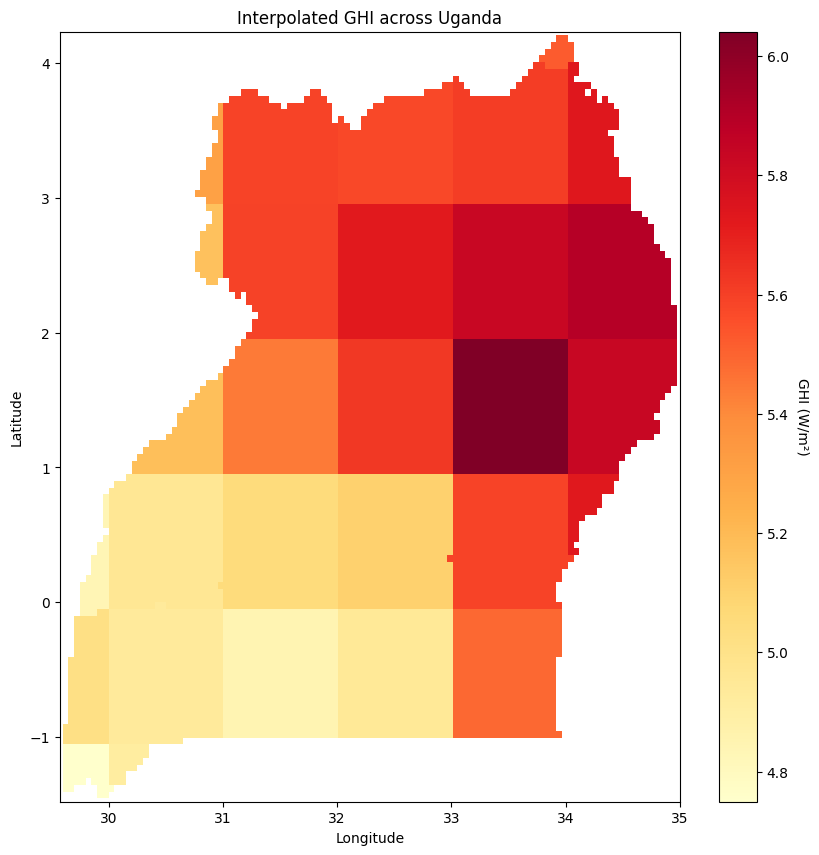

In [48]:
# visualize the results
fig, ax = plt.subplots(figsize=(10, 10))

c = ax.pcolormesh(interp_lons, interp_lats, interpolated_ghi_masked, shading='auto', cmap=COLOR_MAP)
cbar = plt.colorbar(c, ax=ax, orientation='vertical')
cbar.set_label('GHI (W/m²)', rotation=270, labelpad=15)
plt.title('Interpolated GHI across Uganda')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(minx, maxx)
plt.ylim(miny, maxy)
# plt.grid()
# plt.savefig(OUTPUT_FILENAME, dpi=300, bbox_inches='tight')
plt.show()